In [141]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from category_encoders import TargetEncoder , LeaveOneOutEncoder

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import xgboost as xgb

In [9]:
df= pd.read_csv("../data/turkey_used_cars.csv")

In [10]:
df.head()

,brand,model,variant,year,km,color,price,city
0,audi,a1,1.4 TFSI Attraction,2011,155000,White,625000,İstanbul
1,audi,a1,1.6 TDI Ambition,2011,252000,Black,625000,Aydın
2,audi,a1,1.4 TFSI Attraction,2012,203000,Black,665000,Zonguldak
3,audi,a1,1.6 TDI Ambition,2013,270000,White,835000,İstanbul
4,audi,a1,1.6 TDI Attraction,2011,228000,Black,670000,Ankara


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253344 entries, 0 to 253343
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   brand    253344 non-null  object
 1   model    253344 non-null  object
 2   variant  253344 non-null  object
 3   year     253344 non-null  int64 
 4   km       253344 non-null  int64 
 5   color    253344 non-null  object
 6   price    253344 non-null  int64 
 7   city     253344 non-null  object
dtypes: int64(3), object(5)
memory usage: 15.5+ MB


In [13]:
df.shape

(253344, 8)

In [24]:
df.drop_duplicates(inplace=True,ignore_index=True)
df.shape

(253056, 8)

In [14]:
df.describe()

,year,km,price
count,253344.000000,253344.000000,2.533440e+05
mean,2013.971189,168128.632610,1.115800e+06
std,6.516946,76662.113364,9.744306e+05
min,1972.000000,0.000000,1.000000e+05
25%,2011.000000,110000.000000,5.750000e+05
50%,2015.000000,174000.000000,8.800000e+05
75%,2019.000000,230000.000000,1.300000e+06
max,2025.000000,300000.000000,1.000000e+07


In [23]:
df['price'].values.min()

np.int64(10000000)

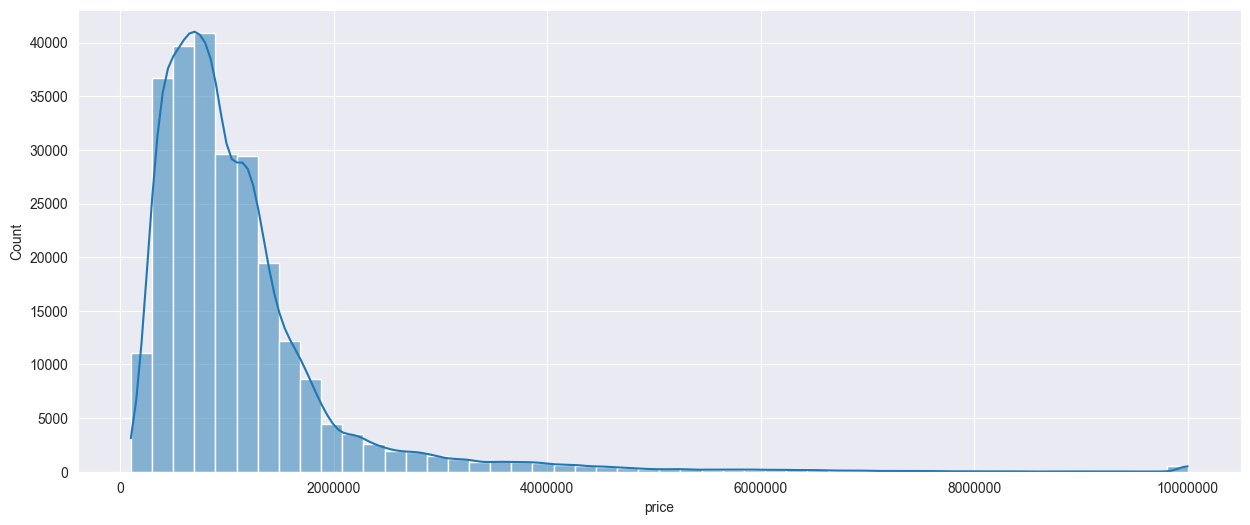

In [25]:
plt.figure(figsize=(15,6))
sns.histplot(data=df['price'] , bins=50, kde=True)
plt.ticklabel_format(style='plain' , axis='x')
plt.show()

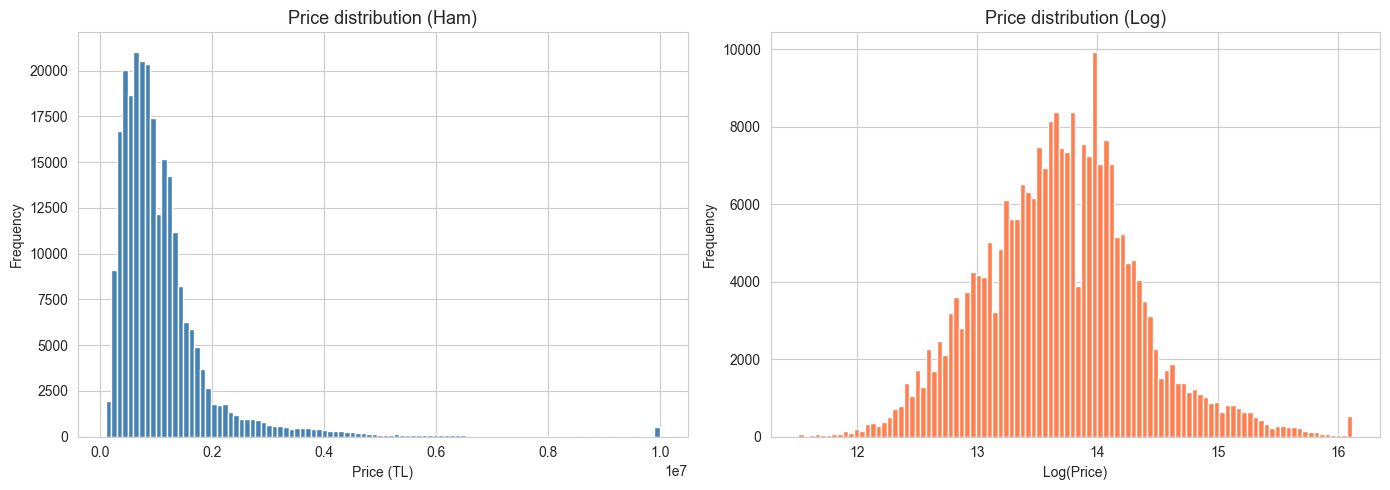

Price statistics:
  Minimum :      100,000 TL
  Average:    1,114,219 TL
  Median  :      880,000 TL
  Maximum:   10,000,000 TL


In [185]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Price distribution (Ham)', fontsize=13)
axes[0].set_xlabel('Price (TL)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['price']), bins=100, color='coral', edgecolor='white')
axes[1].set_title('Price distribution (Log)', fontsize=13)
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Price statistics:')
print(f'  Minimum : {df["price"].min():>12,.0f} TL')
print(f'  Average: {df["price"].mean():>12,.0f} TL')
print(f'  Median  : {df["price"].median():>12,.0f} TL')
print(f'  Maximum: {df["price"].max():>12,.0f} TL')

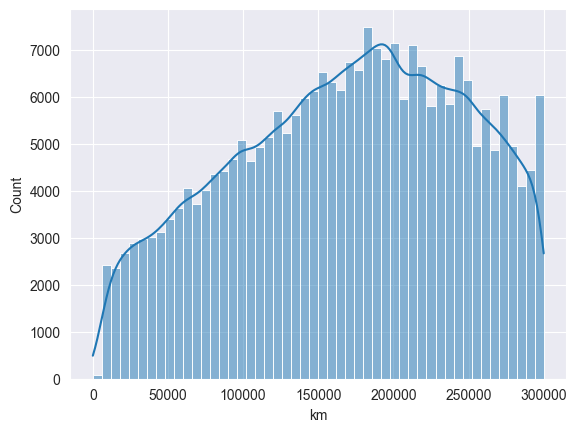

In [26]:
sns.histplot(data=df['km'], bins=50 , kde=True)
plt.show()

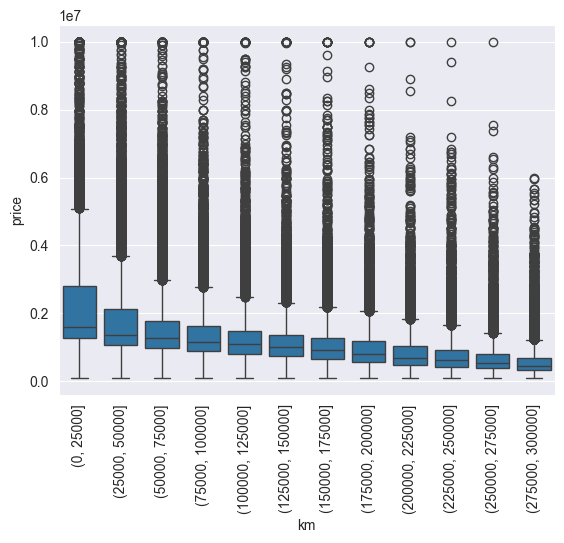

In [27]:
sns.boxplot(
    x=pd.cut(df['km'], bins=range(0, df['km'].max()+25000, 25000)),
    y=df['price']
)
plt.xticks(rotation=90)
plt.show()

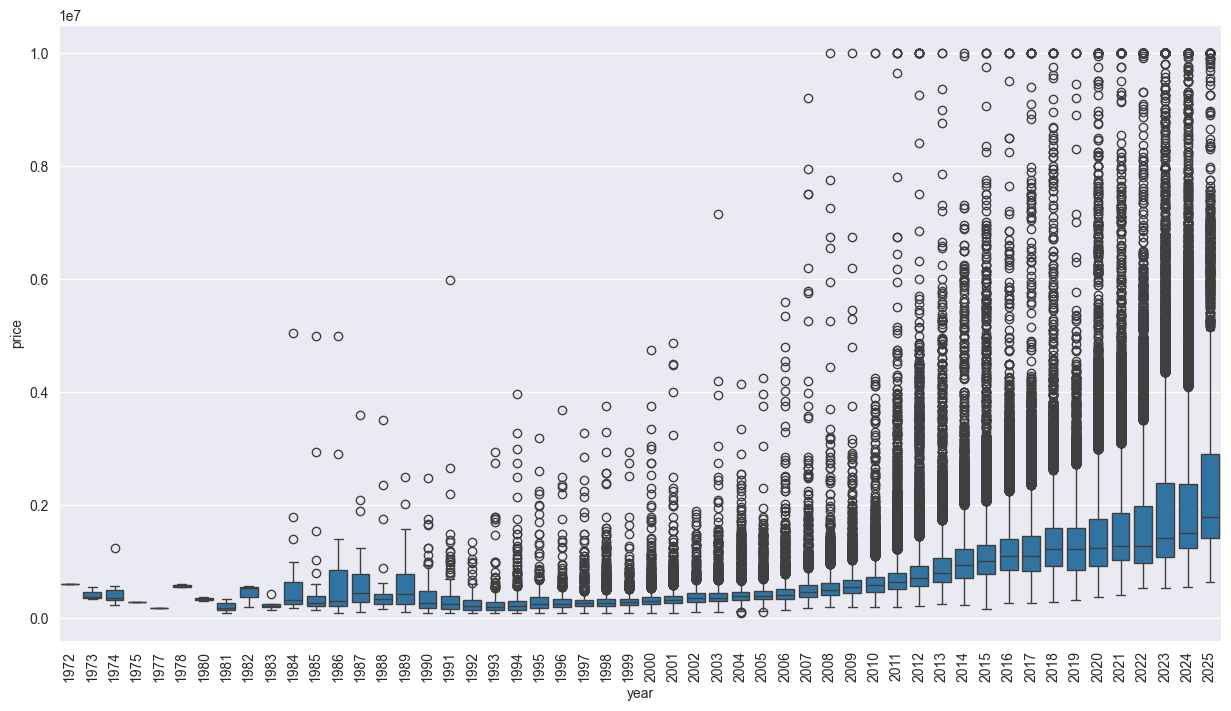

In [28]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df , x='year' , y='price')
plt.xticks(rotation=90)
plt.show()

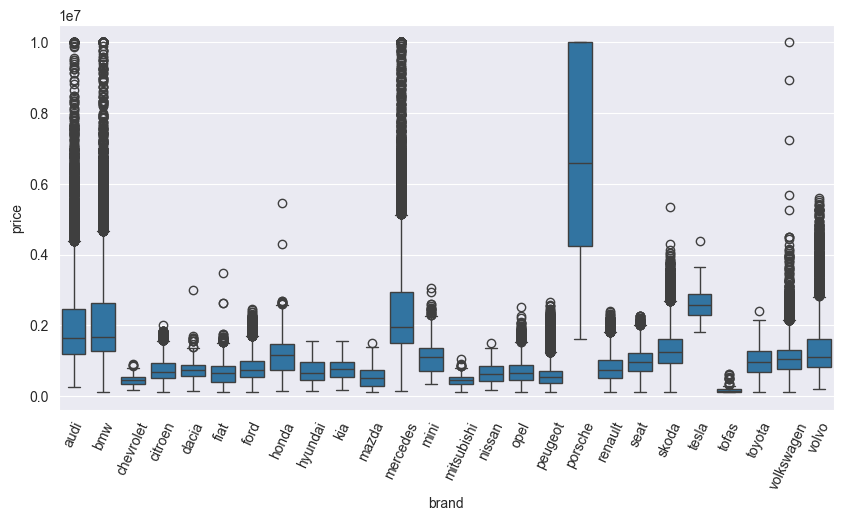

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df , x='brand' ,y='price')
plt.xticks(rotation=65)
plt.show()

In [32]:
for col in ['brand', 'model', 'color', 'city']:
    print(f'{col}: {df[col].nunique()} unique variable')

brand: 26 unique variable
model: 143 unique variable
color: 18 unique variable
city: 83 unique variable


In [36]:
#----------------------------------

In [61]:
dfx = df.copy()

In [62]:
year_now = 2026
dfx['car_age'] = (year_now + 1) - dfx['year']

In [63]:
dfx.loc[dfx['km'] < 5000, 'km'] = 5000

In [64]:
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [65]:
dfx.describe()

,year,km,price,car_age
count,"253,056.00","253,056.00","253,056.00","253,056.00"
mean,"2,013.97","168,182.80","1,114,218.80",13.03
std,6.52,"76,628.55","967,831.64",6.52
min,"1,972.00","5,000.00","100,000.00",2.00
25%,"2,011.00","110,000.00","575,000.00",8.00
50%,"2,015.00","174,000.00","880,000.00",12.00
75%,"2,019.00","230,000.00","1,300,000.00",16.00
max,"2,025.00","300,000.00","10,000,000.00",55.00


In [66]:
#dfx['city'].value_counts()
# we can see there is two different -> diğer, Kardzhali
# lets remove it.

dfx = dfx[~dfx["city"].isin(["Diğer", "Kardzhali"])]
dfx["city"].value_counts()

city
İstanbul     57695
Ankara       25387
İzmir        12853
Antalya      10059
Bursa         9898
             ...  
Iğdır          235
Gümüşhane      169
Bayburt        106
Ardahan         99
Tunceli         85
Name: count, Length: 81, dtype: int64

In [67]:
dfx ['color'].value_counts()

color
White          104685
Gray            35965
Black           33218
Silver Gray     20598
Blue            13862
Red             13121
Smoke Gray      13051
Navy             5747
Brown            2783
Burgundy         2533
Green            2396
Beige            1769
Yellow           1045
Champagne        1024
Orange            634
Turquoise         331
Purple            259
Pink               32
Name: count, dtype: int64

In [68]:
top7 = dfx['color'].value_counts().nlargest(7).index
dfx['color'] = dfx['color'].apply(lambda x: x if x in top7 else 'Other')

In [69]:
dfx['variant'].value_counts()

variant
1.6 TDI BlueMotion Comfortline    4535
1.5 dCi Touch                     3565
1.3 Multijet Easy                 3533
1.6 TDI Comfortline               2623
1.6i VTEC Eco Elegance            2437
                                  ... 
1.4 CL                               2
1.5 GT                               1
1.6  Style                           1
2.0 HDi SV                           1
2.0 Sport Trend                      1
Name: count, Length: 2118, dtype: int64

In [70]:
#There are 2,118 unique variants, and some occur only once, twice, or five times, which could negatively impact the model.

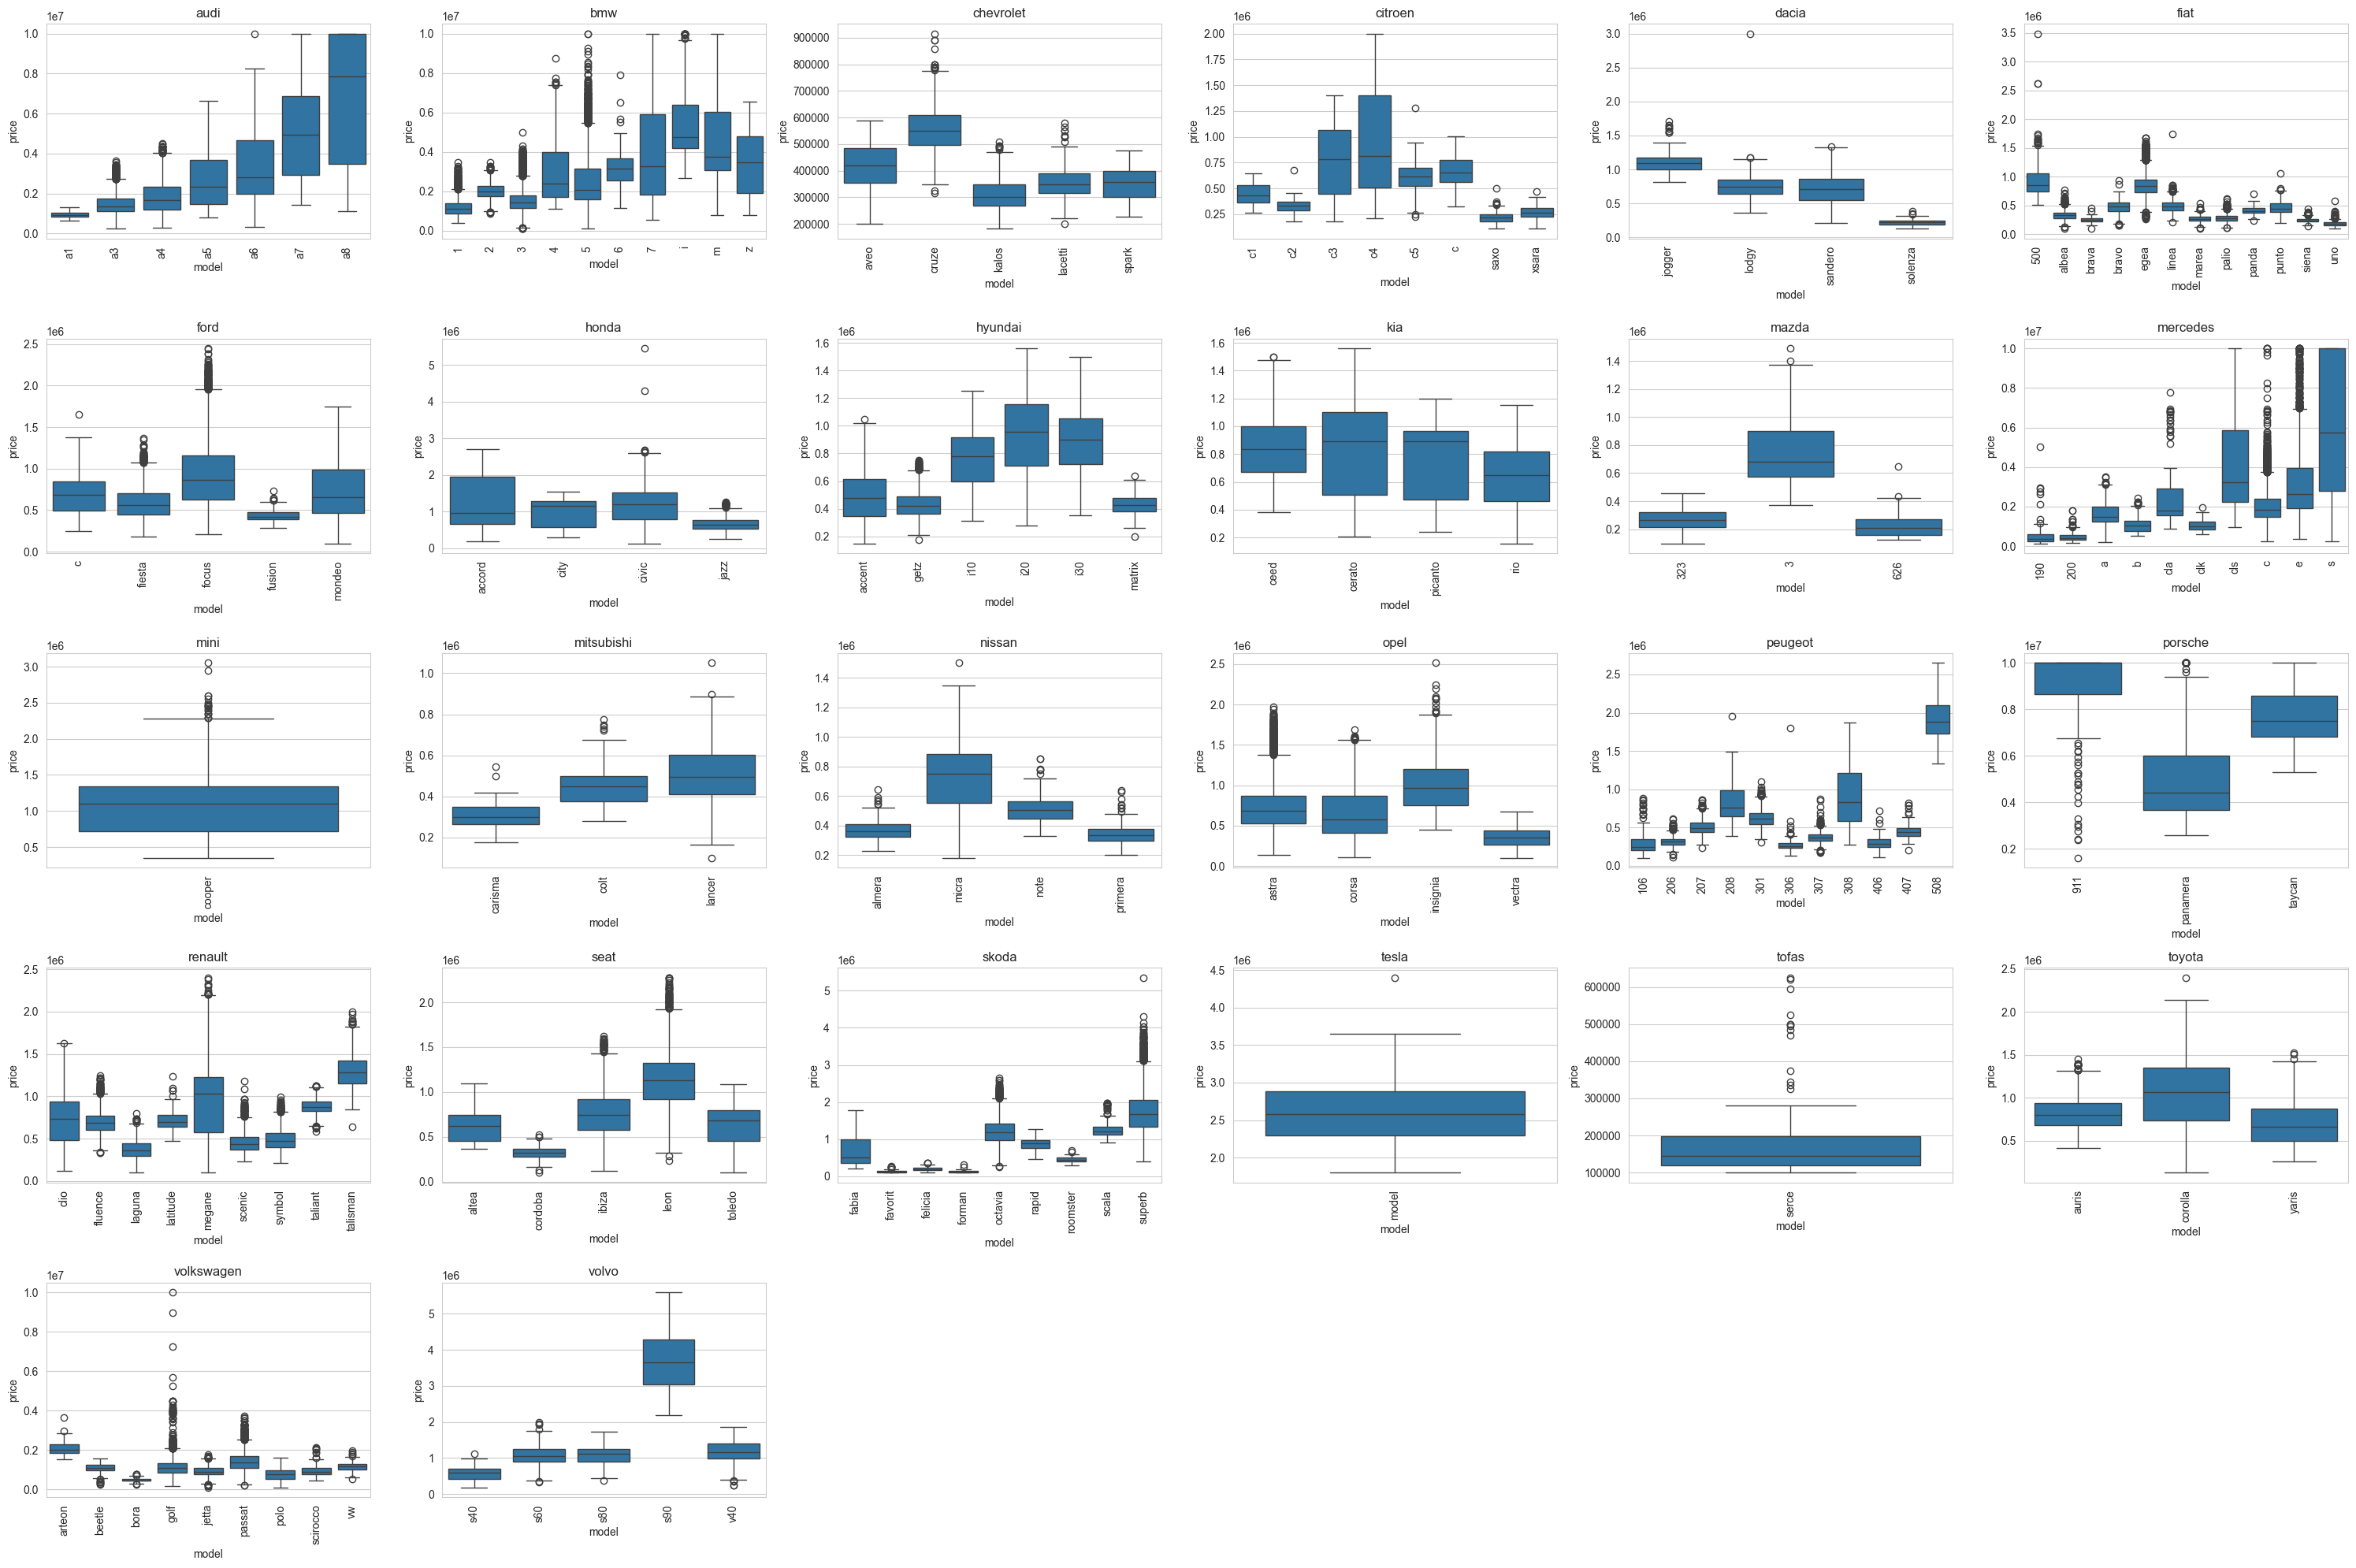

In [72]:
import math
brands = dfx['brand'].unique()
n_brands = len(brands)
n_cols = math.ceil(math.sqrt(n_brands))
n_rows = math.ceil(n_brands / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()
for i, brand in enumerate(brands):
    brand_df = dfx[dfx['brand'] == brand]
    sns.boxplot(
        data=brand_df,
        x='model',
        y='price',
        ax=axes[i]
    )
    axes[i].set_title(brand)
    axes[i].tick_params(axis='x', rotation=90)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [92]:
def variant_group_info(dfx):
    vgi_list = []
    for brand, group in dfx.groupby("brand"):
        unique_variants = group["variant"].dropna().unique()
        vgi_s = (
            f"{brand} counts "
            f"{len(unique_variants)} counts of unique variants.\n\n"
            f"variant:\n- " + "\n- ".join(sorted(unique_variants))
        )
        vgi_list.append(vgi_s)
    return "\n\n" + "="*80 + "\n\n".join(vgi_list)

In [93]:
print(variant_group_info(dfx)[:10])

In [94]:
dfx["engine_raw"] = dfx["variant"].str.extract(r'(\d\.\d)')
dfx["engine_cc"] = (
    dfx["engine_raw"]
    .str.replace(".", "", regex=False)
    .astype(float)
    .mul(100)
)
dfx["engine_cc"] = dfx["engine_cc"].fillna("unknown")
dfx.drop(columns="engine_raw", inplace=True)

In [95]:
dfx.loc[dfx['engine_cc'] == 'unknown', 'brand'].value_counts()

brand
bmw         18330
mercedes    14195
audi         3574
tesla         785
porsche       767
fiat          648
peugeot       256
tofas         141
skoda         136
Name: count, dtype: int64

In [96]:
def extract_bmw_engine_cc(row):
    if row["brand"] != "bmw":
        return row["engine_cc"]
    if not isinstance(row["engine_cc"], str):
        return row["engine_cc"]
    variant = str(row["variant"]).lower()
    match = re.search(r"(\d{3})", variant)
    if not match:
        return "unknown"
    code = match.group(1)
    return int(code[1:]) * 100

In [97]:
dfx["engine_cc"] = dfx.apply(extract_bmw_engine_cc, axis=1)

In [98]:
def extract_mercedes_cc(row):
    if row['brand'].lower() != 'mercedes':
        return row['engine_cc']
    if row['engine_cc'] != 'unknown':
        return row['engine_cc']
    matches = re.findall(r'\b(\d{3})\b', row['variant'])
    if matches:
        return int(matches[0]) * 10
    else:
        return 'unknown'
dfx['engine_cc'] = dfx.apply(extract_mercedes_cc, axis=1)

In [99]:
dfx["engine_cc"] = pd.to_numeric(dfx["engine_cc"], errors="coerce")

In [100]:
dfx = dfx[~dfx['brand'].isin(['tesla', 'tofas' , 'porsche' , 'mini'])]

In [101]:
((dfx['variant'].value_counts()) < 30 ).sum()

np.int64(919)

In [102]:
variant_counts = dfx['variant'].value_counts()
dfx['variant'] = dfx['variant'].apply(lambda x: x if variant_counts[x] >= 30 else 'rare_variant')

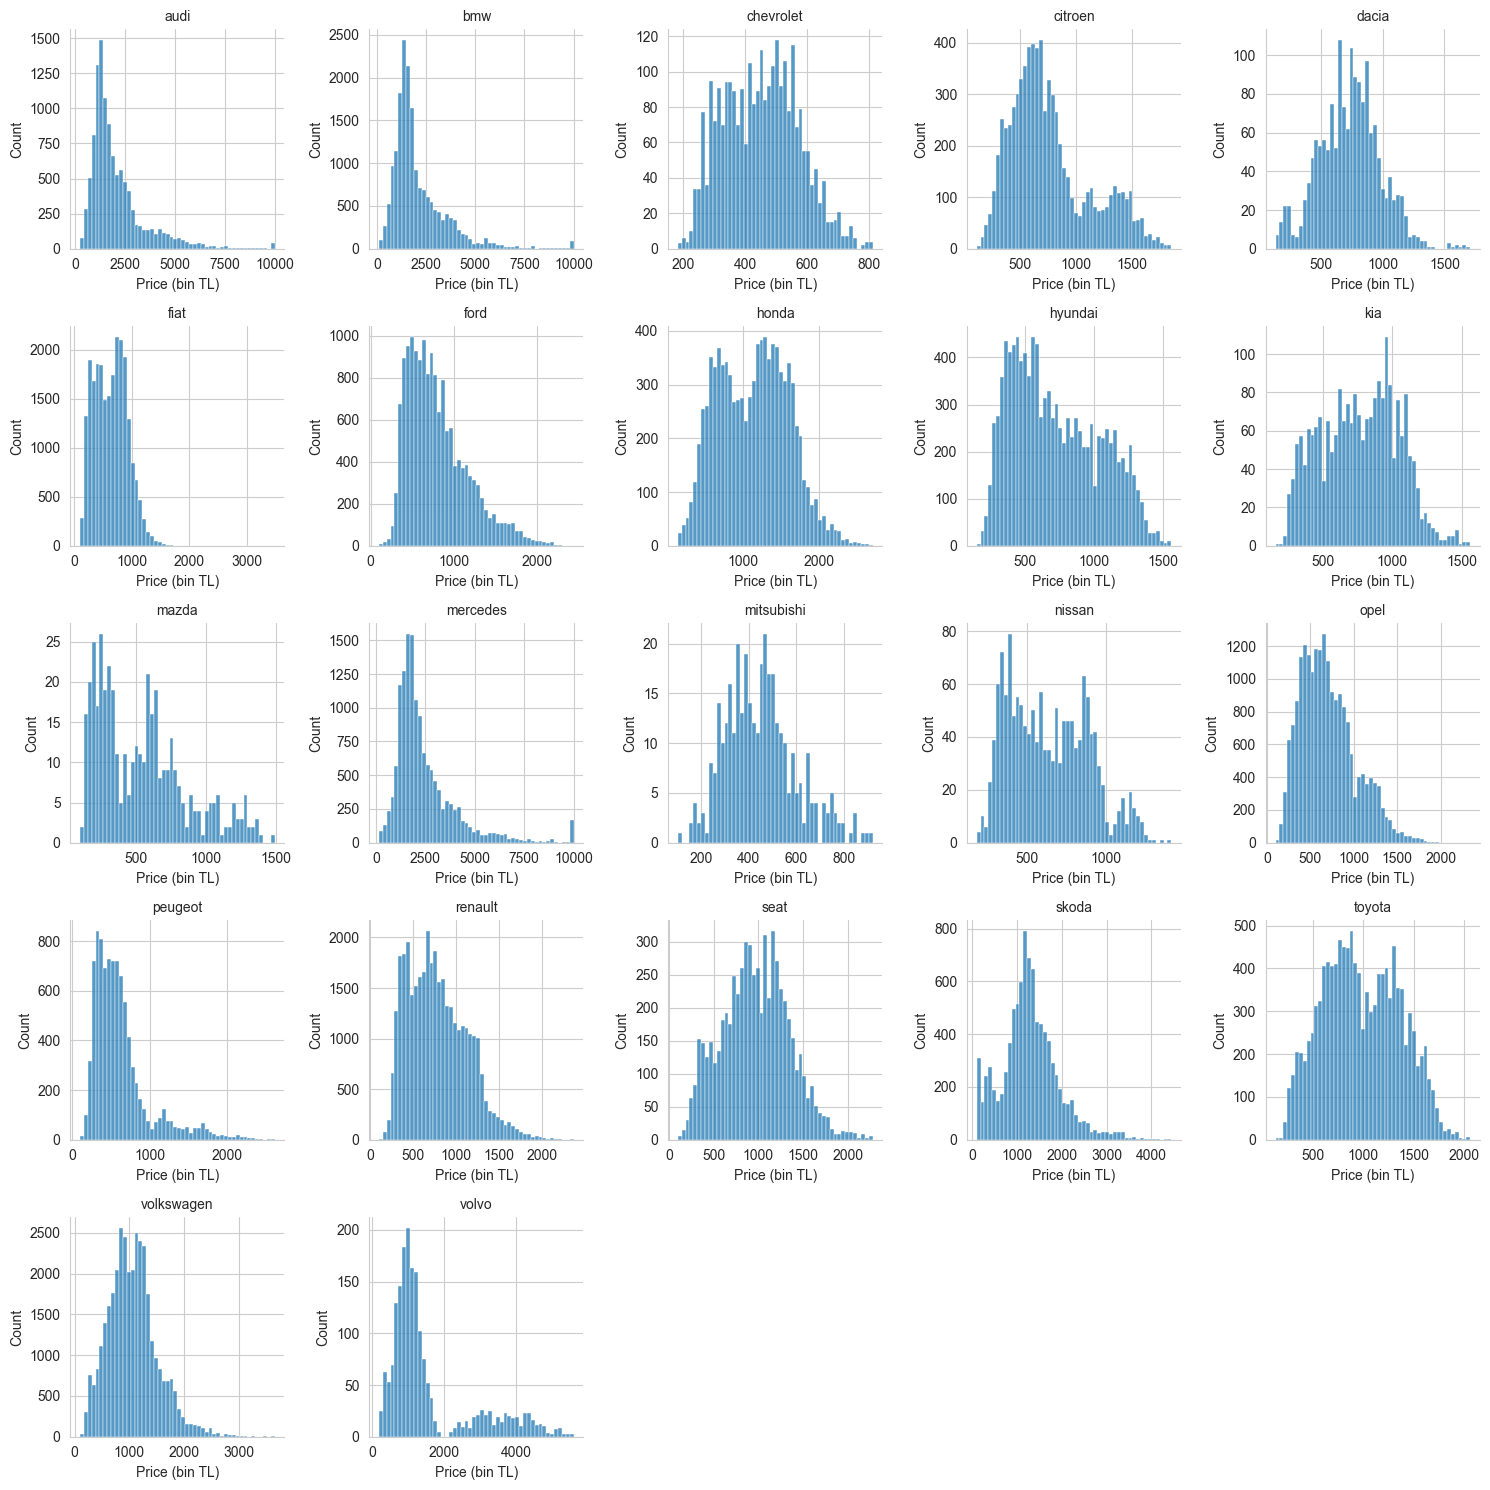

In [104]:
from matplotlib.ticker import FuncFormatter
def thousands_formatter(x, pos):
    return f"{int(x/1000)}"
all_brands = dfx['brand'].value_counts().index
g = sns.FacetGrid(
    dfx[dfx['brand'].isin(all_brands)],
    col="brand",
    col_wrap=5,
    height=3,
    sharex=False,
    sharey=False
)
g.map_dataframe(sns.histplot, x="price", bins=50)
for ax in g.axes.flatten():
    ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    ax.set_xlabel("Price (bin TL)")
g.set_titles("{col_name}")
g.tight_layout()
plt.show()

In [76]:
#log transformation will be much more appropriate choice.
dfx['log_price'] = np.log1p(dfx['price'])

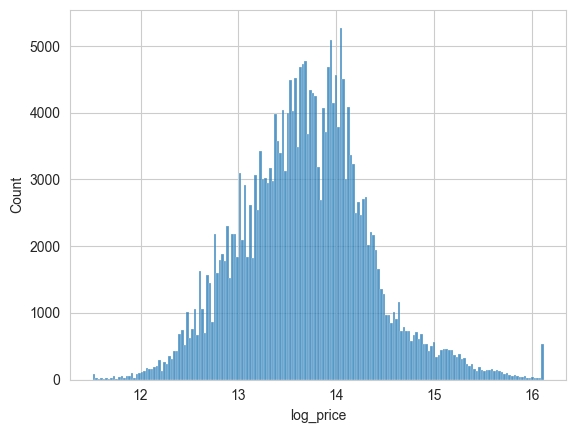

In [77]:
sns.histplot(data=dfx,x='log_price')
plt.show()

In [79]:
dfx.corr(numeric_only=True)

,year,km,price,car_age,log_price
year,1.00,-0.65,0.50,-1.00,0.74
km,-0.65,1.00,-0.44,0.65,-0.55
price,0.50,-0.44,1.00,-0.50,0.85
car_age,-1.00,0.65,-0.50,1.00,-0.74
log_price,0.74,-0.55,0.85,-0.74,1.00


In [80]:
unique_counts = df.groupby(['brand', 'model', 'year']).size()
num_unique_combinations = unique_counts.shape[0]
print(f"unique brand-model-year combinations: {num_unique_combinations}")
print(unique_counts.sort_values(ascending=False))

unique brand-model-year combinations: 2227
brand     model  year
fiat      egea   2020    1829
                 2022    1781
                 2023    1693
                 2017    1384
                 2019    1338
                         ... 
mercedes  s      1991       1
fiat      panda  2017       1
          punto  2000       1
                 2003       1
volvo     v40    1997       1
Length: 2227, dtype: int64


In [82]:
small_groups_count = (unique_counts < 5).sum()
print(f"less then 19: {small_groups_count}")

less then 19: 328


In [83]:
group_cols = ["brand", "model", "year"]

stats = (
    dfx
    .groupby(group_cols)["price"]
    .agg(
        count="count",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

stats["iqr"] = stats["q3"] - stats["q1"]

stats["iqr_multiplier"] = np.select(
    [
        stats["count"] < 5,
        stats["count"].between(5, 19),
        stats["count"] >= 20
    ],
    [
        np.nan,
        2.5,
        1.5
    ]
)

stats["lower_bound"] = stats["q1"] - stats["iqr_multiplier"] * stats["iqr"]
stats["upper_bound"] = stats["q3"] + stats["iqr_multiplier"] * stats["iqr"]

dfx = dfx.merge(
    stats[
        "brand model year lower_bound upper_bound".split()
    ],
    on=group_cols,
    how="left"
)

dfx["price"] = dfx["price"].astype(float)

outlier_mask = (
    (dfx["price"] < dfx["lower_bound"]) |
    (dfx["price"] > dfx["upper_bound"])
)

dfx.loc[dfx["price"] < dfx["lower_bound"], "price"] = dfx.loc[
    dfx["price"] < dfx["lower_bound"], "lower_bound"
]

dfx.loc[dfx["price"] > dfx["upper_bound"], "price"] = dfx.loc[
    dfx["price"] > dfx["upper_bound"], "upper_bound"
]

dfx.drop(
    columns=["lower_bound", "upper_bound"],
    inplace=True,
    errors="ignore"
)

In [84]:
print("Changed rows:", outlier_mask.sum())

Changed rows: 4371


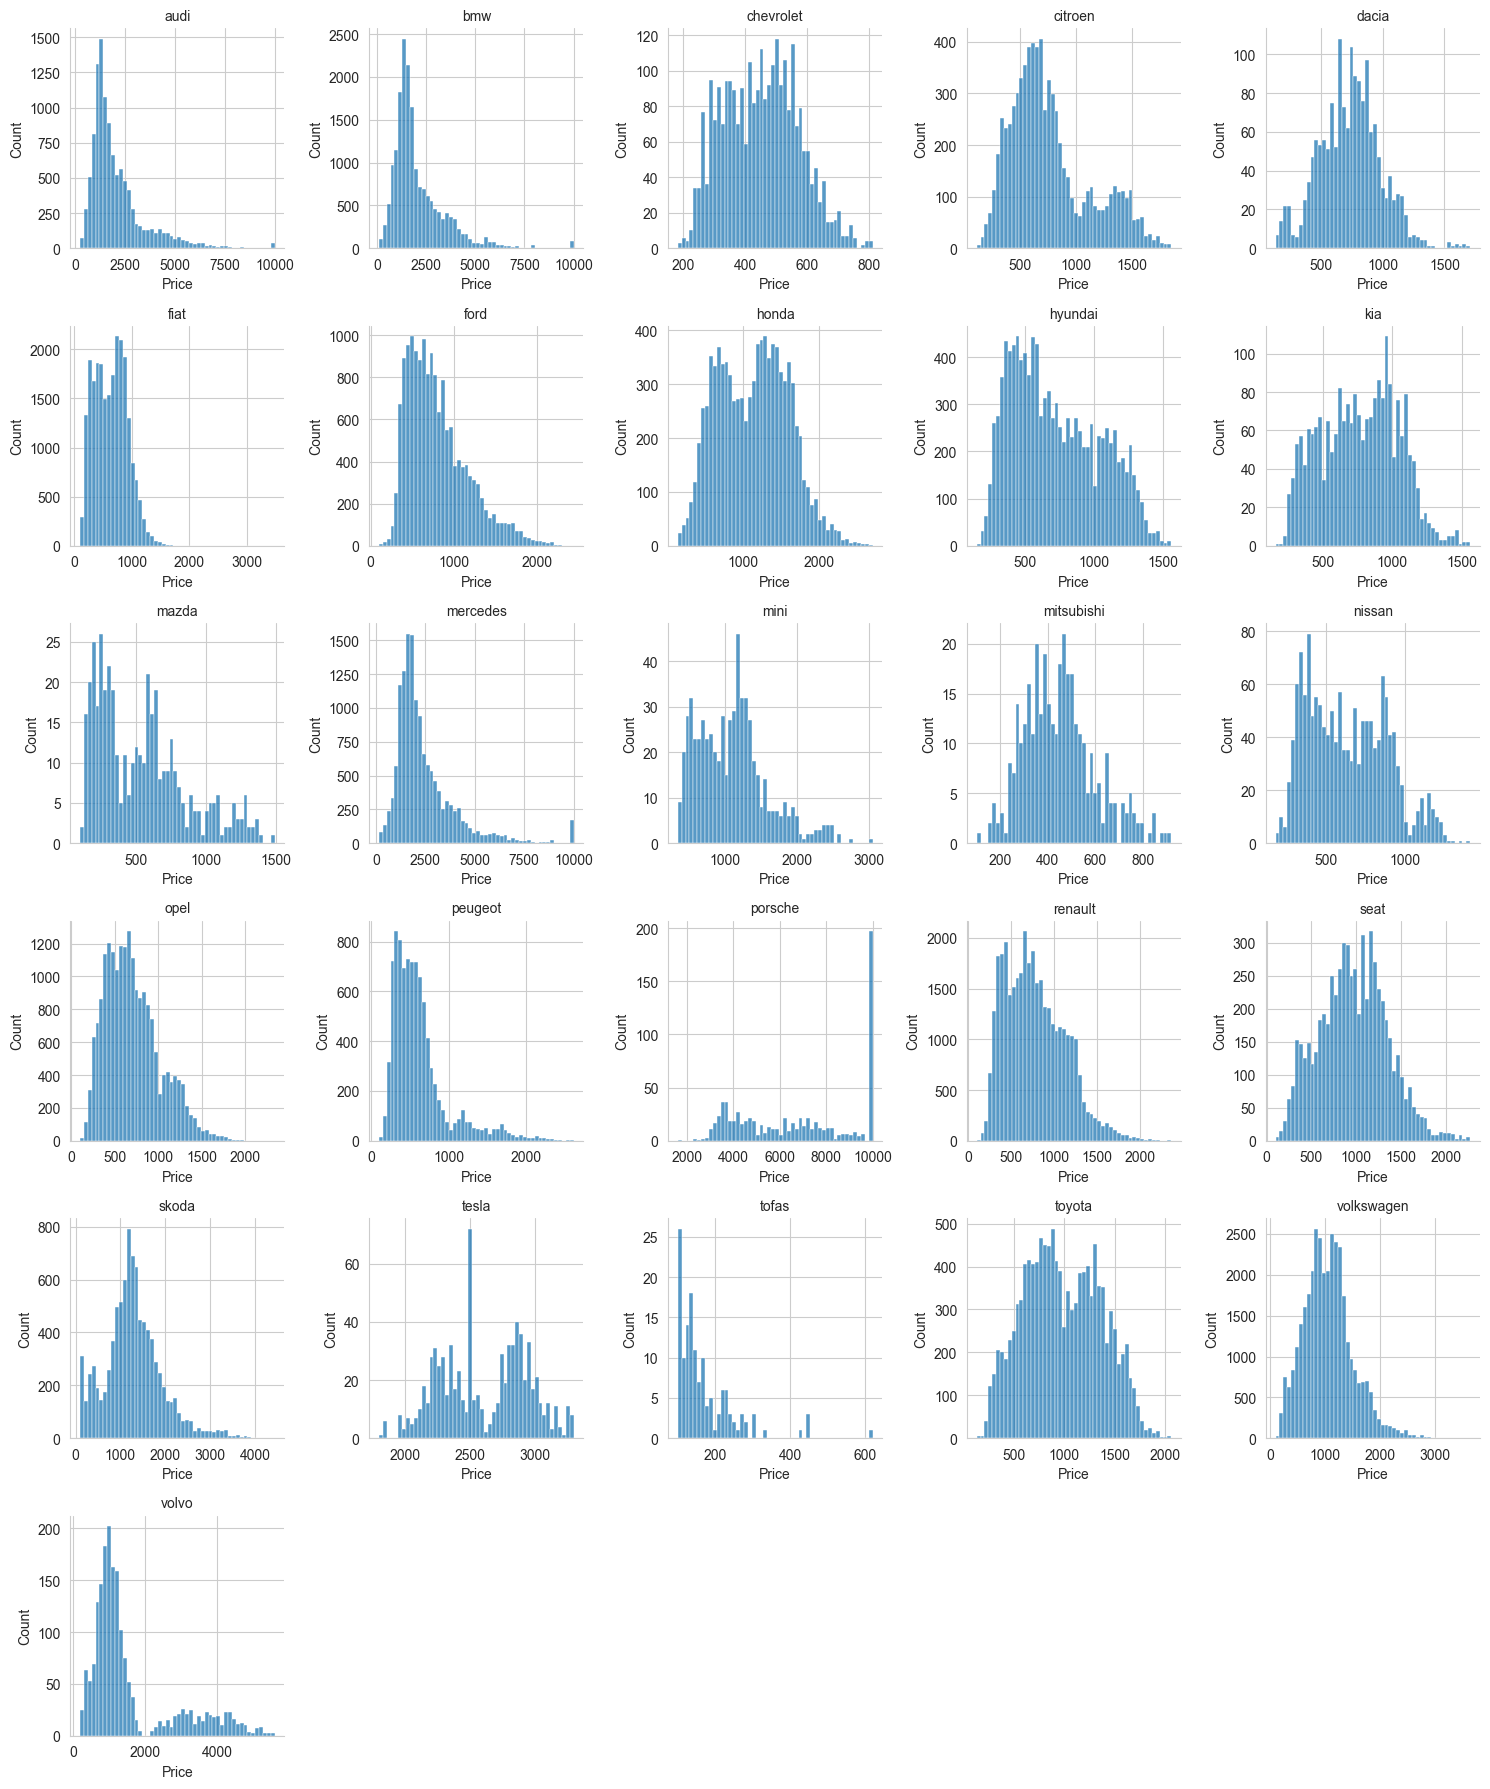

In [87]:
from matplotlib.ticker import FuncFormatter
def formatter1(x, pos):
    return f"{int(x / 1000)}"
a_brands = dfx['brand'].value_counts().index
facet_grid = sns.FacetGrid(
    dfx[dfx['brand'].isin(a_brands)],
    col="brand",
    col_wrap=5,
    height=3,
    sharex=False,
    sharey=False
)
facet_grid.map_dataframe(sns.histplot, x="price", bins=50)

for ax_i in facet_grid.axes.flatten():
    ax_i.xaxis.set_major_formatter(FuncFormatter(formatter1))
    ax_i.set_xlabel("Price")
facet_grid.set_titles("{col_name}")
facet_grid.tight_layout()
plt.show()

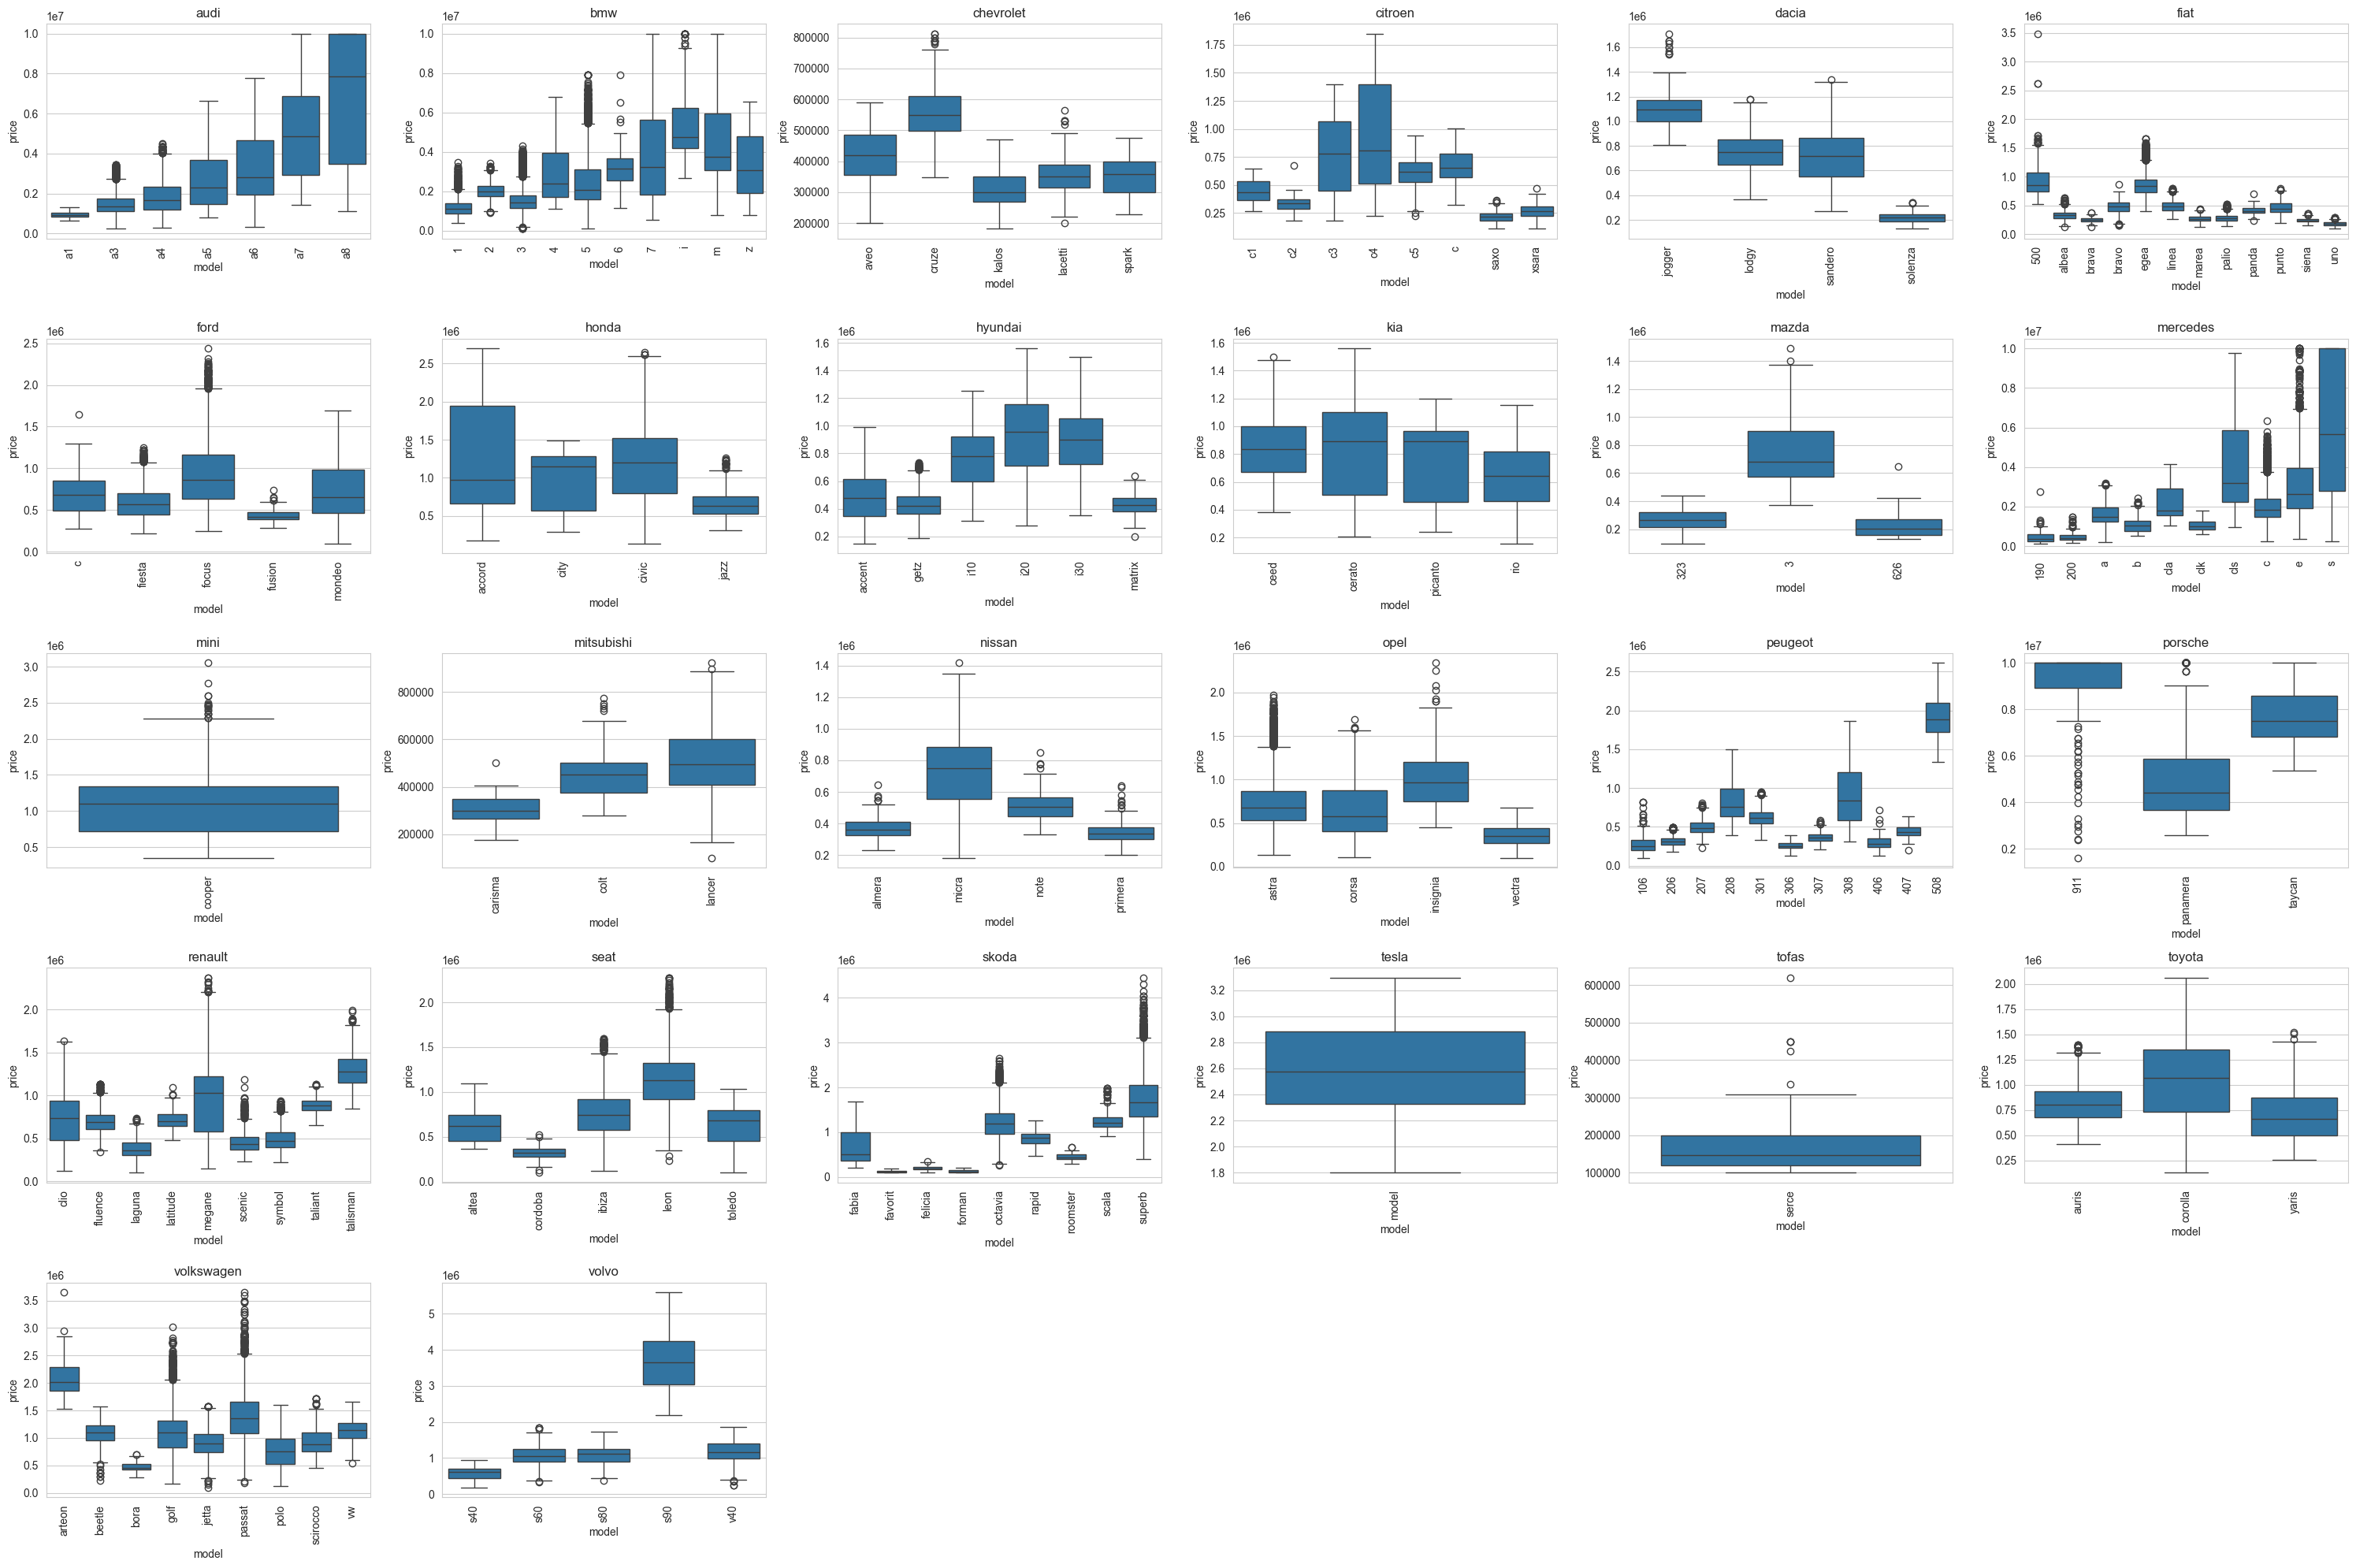

In [88]:
filtered_df = dfx.groupby(['brand', 'model']).filter(lambda grp: len(grp) >= 1)
brand_list = filtered_df['brand'].unique()
brand_count = len(brand_list)
col_count = math.ceil(math.sqrt(brand_count))
row_count = math.ceil(brand_count / col_count)
figure, axis_array = plt.subplots(row_count, col_count, figsize=(5 * col_count, 4 * row_count))
axis_array = axis_array.flatten()
for idx, brand_name in enumerate(brand_list):
    single_brand_df = filtered_df[filtered_df['brand'] == brand_name]
    sns.boxplot(
        data=single_brand_df,
        x='model',
        y='price',
        ax=axis_array[idx]
    )
    axis_array[idx].set_title(brand_name)
    axis_array[idx].tick_params(axis='x', rotation=90)
for empty_idx in range(idx + 1, len(axis_array)):
    figure.delaxes(axis_array[empty_idx])
plt.tight_layout()
plt.show()

In [106]:
dfx.head()

,brand,model,variant,year,km,color,price,city,car_age,log_price,engine_cc
0,audi,a1,rare_variant,2011,155000,White,"625,000.00",İstanbul,16,13.35,"1,400.00"
1,audi,a1,1.6 TDI Ambition,2011,252000,Black,"625,000.00",Aydın,16,13.35,"1,600.00"
2,audi,a1,rare_variant,2012,203000,Black,"665,000.00",Zonguldak,15,13.41,"1,400.00"
3,audi,a1,1.6 TDI Ambition,2013,270000,White,"835,000.00",İstanbul,14,13.64,"1,600.00"
4,audi,a1,1.6 TDI Attraction,2011,228000,Black,"670,000.00",Ankara,16,13.42,"1,600.00"


In [107]:
dfx.isna().sum()

brand           0
model           0
variant         0
year            0
km              0
color           0
price           0
city            0
car_age         0
log_price       0
engine_cc    5365
dtype: int64

In [108]:
dfx['engine_cc'] = dfx['engine_cc'].fillna(dfx['engine_cc'].median())

In [109]:
dfx.drop(columns=["year"], inplace=True)

In [110]:
df.head(1)

,brand,model,variant,year,km,color,price,city
0,audi,a1,1.4 TFSI Attraction,2011,155000,White,625000,İstanbul


In [111]:
dfx.head(1)

,brand,model,variant,km,color,price,city,car_age,log_price,engine_cc
0,audi,a1,rare_variant,155000,White,"625,000.00",İstanbul,16,13.35,"1,400.00"


In [157]:
df_clean=df.copy()

In [158]:
year_now = 2026
df_clean['car_age'] = (year_now +1) - df_clean['year']
df_clean.loc[df_clean['km'] < 5000, 'km'] = 5000

df_clean = df_clean[~df_clean["city"].isin(["Diğer", "Kardzhali"])]
top7 = df_clean['color'].value_counts().nlargest(7).index
df_clean['color'] = df_clean['color'].apply(lambda x: x if x in top7 else 'Other')
df_clean["engine_raw"] = df_clean["variant"].str.extract(r'(\d\.\d)')
df_clean["engine_cc"] = (
    df_clean["engine_raw"]
    .str.replace(".", "", regex=False)
    .astype(float)
    .mul(100)
)
df_clean["engine_cc"] = df_clean["engine_cc"].fillna("unknown")
df_clean.drop(columns="engine_raw", inplace=True)
def extract_bmw_engine_cc(row):
    if row["brand"] != "bmw":
        return row["engine_cc"]
    if not isinstance(row["engine_cc"], str):
        return row["engine_cc"]
    variant = str(row["variant"]).lower()
    match = re.search(r"(\d{3})", variant)
    if not match:
        return "unknown"
    code = match.group(1)
    return int(code[1:]) * 100
df_clean["engine_cc"] = df_clean.apply(extract_bmw_engine_cc, axis=1)
def extract_mercedes_cc(row):
    if row['brand'].lower() != 'mercedes':
        return row['engine_cc']
    if row['engine_cc'] != 'unknown':
        return row['engine_cc']
    matches = re.findall(r'\b(\d{3})\b', row['variant'])
    if matches:
        return int(matches[0]) * 10
    else:
        return 'unknown'
df_clean['engine_cc'] = df_clean.apply(extract_mercedes_cc, axis=1)
df_clean["engine_cc"] = pd.to_numeric(df_clean["engine_cc"], errors="coerce")
df_clean = df_clean[~df_clean['brand'].isin(['tesla', 'tofas' , 'porsche' , 'mini'])]
variant_counts = df_clean['variant'].value_counts()
df_clean['variant'] = df_clean['variant'].apply(lambda x: x if variant_counts[x] >= 30 else 'rare_variant')
df_clean['log_price'] = np.log1p(df_clean['price'])
df_clean = df_clean[df_clean['car_age'] <= 34]
df_clean['engine_cc'] = df_clean['engine_cc'].fillna(
    df_clean.groupby(['brand', 'model'])['engine_cc'].transform('median')
)
df_clean['engine_cc'] = df_clean['engine_cc'].fillna(
    df_clean.groupby('brand')['engine_cc'].transform('median')
)
df_clean['engine_cc'] = df_clean['engine_cc'].fillna(df_clean['engine_cc'].median())
df_clean.drop(columns=["year"], inplace=True)

In [159]:
df_clean.head()

,brand,model,variant,km,color,price,city,car_age,engine_cc,log_price
0,audi,a1,rare_variant,155000,White,625000,İstanbul,16,"1,400.00",13.35
1,audi,a1,1.6 TDI Ambition,252000,Black,625000,Aydın,16,"1,600.00",13.35
2,audi,a1,rare_variant,203000,Black,665000,Zonguldak,15,"1,400.00",13.41
3,audi,a1,1.6 TDI Ambition,270000,White,835000,İstanbul,14,"1,600.00",13.64
4,audi,a1,1.6 TDI Attraction,228000,Black,670000,Ankara,16,"1,600.00",13.42


In [160]:
df_clean.describe()

,km,price,car_age,engine_cc,log_price
count,"250,121.00","250,121.00","250,121.00","250,121.00","250,121.00"
mean,"168,723.15","1,094,579.70",13.00,"1,533.30",13.69
std,"76,204.96","906,786.85",6.37,314.24,0.64
min,"5,000.00","100,000.00",2.00,800.00,11.51
25%,"110,000.00","575,000.00",9.00,"1,400.00",13.26
50%,"175,000.00","879,000.00",12.00,"1,500.00",13.69
75%,"230,000.00","1,298,000.00",16.00,"1,600.00",14.08
max,"300,000.00","10,000,000.00",34.00,"6,000.00",16.12


In [161]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250121 entries, 0 to 253055
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   brand      250121 non-null  object 
 1   model      250121 non-null  object 
 2   variant    250121 non-null  object 
 3   km         250121 non-null  int64  
 4   color      250121 non-null  object 
 5   price      250121 non-null  int64  
 6   city       250121 non-null  object 
 7   car_age    250121 non-null  int64  
 8   engine_cc  250121 non-null  float64
 9   log_price  250121 non-null  float64
dtypes: float64(2), int64(3), object(5)
memory usage: 21.0+ MB


In [162]:
X = df_clean.drop(columns=["price", "log_price"])
y = df_clean["log_price"]

In [163]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [164]:
num_cols = ["km", "car_age", "engine_cc"]
low_cardinality_cat_cols = ["color", "city", "brand"]
high_cardinality_cat_cols = ["model", "variant"]

In [165]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
low_cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
high_cat_target_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target_enc", TargetEncoder(
        smoothing=50,
        min_samples_leaf=100
    ))
])
high_cat_loo_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("loo_enc", LeaveOneOutEncoder(
        sigma=0.1,
        random_state=42
    ))
])

In [166]:
preprocess_target = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("low_cat", low_cat_pipe, low_cardinality_cat_cols),
        ("high_cat", high_cat_target_pipe, high_cardinality_cat_cols)
    ],
    remainder="drop"
)

In [167]:
preprocess_target.set_output(transform="pandas")

,transformers,"[('num', ...), ('low_cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [168]:
def regression_metrics(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return {
        "R2_log": r2_score(y_true_log, y_pred_log),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred)
    }

In [169]:
models = {

    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=500, max_depth=8, random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=8, random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, tree_method="hist"
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )
}

In [172]:
results = {}

for name, model in models.items():
    print(f'⏳ {name} training...')

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocess_target),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred_log = pipeline.predict(X_test)

    metrics = regression_metrics(y_test, y_pred_log)

    #mae  = mean_absolute_error(y_test, y_pred)
    #rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    #r2   = r2_score(y_test, y_pred)

    results[name] = {'MAE': metrics["MAE"], 'RMSE': metrics["RMSE"], 'R2': metrics["R2_log"], 'pipeline': pipeline}
    print(f'  ✅ MAE: {metrics["MAE"]:>10,.0f} TL | RMSE: {metrics["RMSE"]:>10,.0f} TL | R²: {metrics["R2_log"]:.4f}\n')

⏳ Linear training...
  ✅ MAE:    149,257 TL | RMSE:    328,082 TL | R²: 0.9214

⏳ RandomForest training...
  ✅ MAE:    133,281 TL | RMSE:    244,164 TL | R²: 0.9283

⏳ GradientBoosting training...
  ✅ MAE:     85,190 TL | RMSE:    150,744 TL | R²: 0.9644

⏳ XGBoost training...
  ✅ MAE:     84,637 TL | RMSE:    149,423 TL | R²: 0.9649

⏳ LightGBM training...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 921
[LightGBM] [Info] Number of data points in the train set: 200096, number of used features: 116
[LightGBM] [Info] Start training from score 13.687352
  ✅ MAE:     91,974 TL | RMSE:    168,757 TL | R²: 0.9614



In [173]:
results_df = pd.DataFrame({
    name: {'MAE (TL)': f"{v['MAE']:,.0f}", 'RMSE (TL)': f"{v['RMSE']:,.0f}", 'R² Skoru': f"{v['R2']:.4f}"}
    for name, v in results.items()
}).T

print('=== MODEL KARŞILAŞTIRMA TABLOSU ===')
display(results_df)

=== MODEL KARŞILAŞTIRMA TABLOSU ===


,MAE (TL),RMSE (TL),R² Skoru
Linear,"149,257","328,082",0.9214
RandomForest,"133,281","244,164",0.9283
GradientBoosting,"85,190","150,744",0.9644
XGBoost,"84,637","149,423",0.9649
LightGBM,"91,974","168,757",0.9614


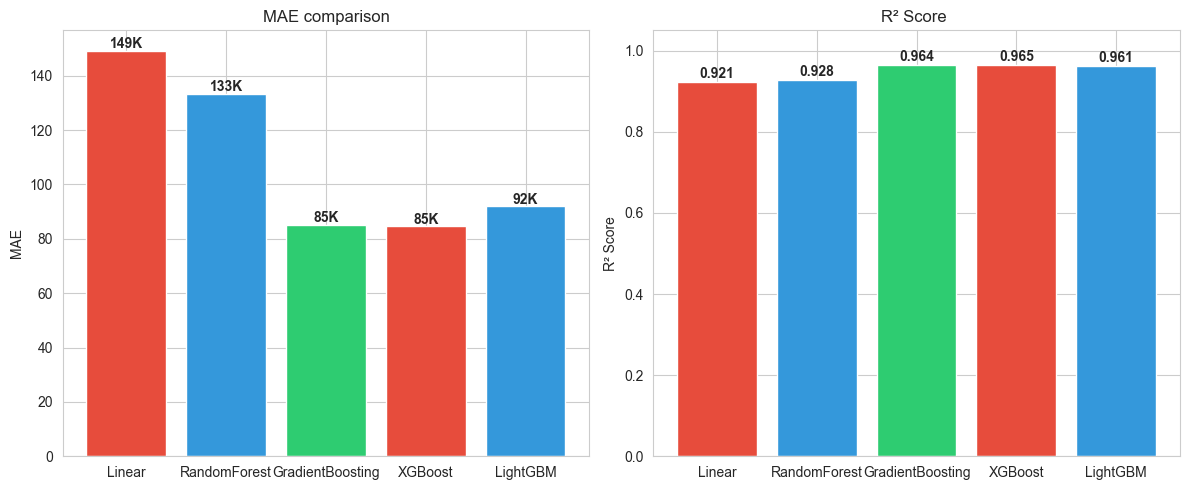

In [175]:
model_names = list(results.keys())
maes  = [results[m]['MAE'] / 1000 for m in model_names]   # bin TL
r2s   = [results[m]['R2'] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(model_names, maes, color=['#e74c3c','#3498db','#2ecc71'])
axes[0].set_title('MAE comparison', fontsize=12)
axes[0].set_ylabel('MAE')
for bar, val in zip(bars1, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}K', ha='center', fontweight='bold')

bars2 = axes[1].bar(model_names, r2s, color=['#e74c3c','#3498db','#2ecc71'])
axes[1].set_title('R² Score ', fontsize=12)
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.05)
for bar, val in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [176]:
best_name = max(results, key=lambda x: results[x]['R2'])
best_pipeline = results[best_name]['pipeline']

print(f'🏆Best model: {best_name}')
print(f'   R²  : {results[best_name]["R2"]:.4f}')
print(f'   MAE : {results[best_name]["MAE"]:,.0f} TL')
print(f'   RMSE: {results[best_name]["RMSE"]:,.0f} TL')

🏆Best model: XGBoost
   R²  : 0.9649
   MAE : 84,637 TL
   RMSE: 149,423 TL


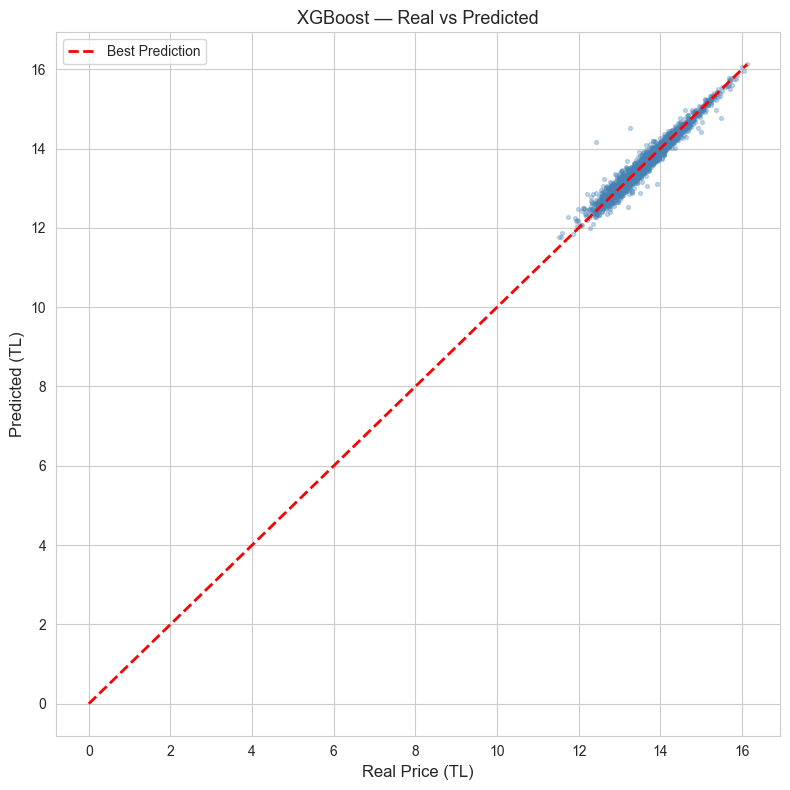

In [177]:
y_pred_best = best_pipeline.predict(X_test)

sample_idx = np.random.choice(len(y_test), 3000, replace=False)
y_true_sample = np.array(y_test)[sample_idx]
y_pred_sample = y_pred_best[sample_idx]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_true_sample, y_pred_sample, alpha=0.3, s=8, color='steelblue')
max_val = max(y_true_sample.max(), y_pred_sample.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Best Prediction')
ax.set_xlabel('Real Price (TL)', fontsize=12)
ax.set_ylabel('Predicted (TL)', fontsize=12)
ax.set_title(f'{best_name} — Real vs Predicted', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

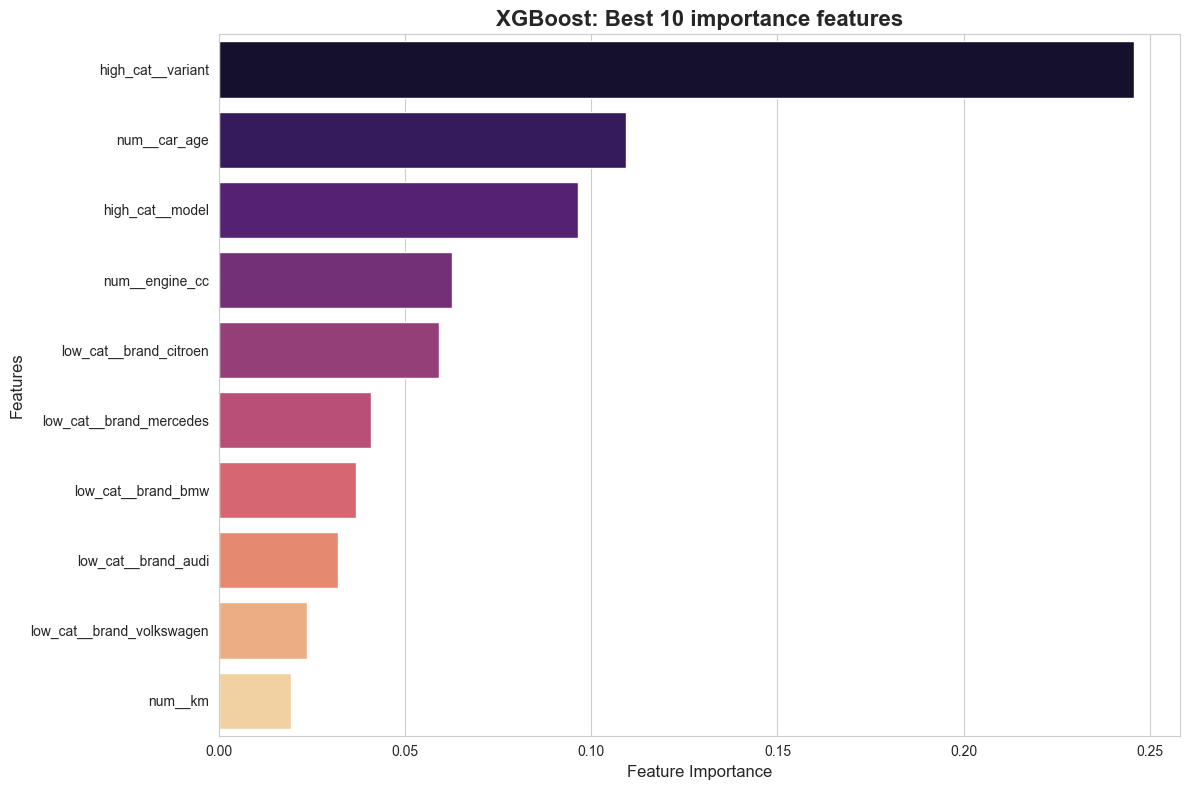

In [181]:
xgboost_model = best_pipeline.named_steps['model']
preprocessor = best_pipeline.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()

importances = xgboost_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='magma')

plt.title('XGBoost: Best 10 importance features', fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

In [184]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'model__n_estimators': [300, 500, 800],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [6, 8, 10],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9]
}

tune_pipeline = Pipeline(steps=[
    ('preprocessor', preprocess_target),
    ('model', XGBRegressor(random_state=42, tree_method="hist"))
])

random_search = RandomizedSearchCV(
    estimator=tune_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("\n🏆 Best Parameters:")
print(random_search.best_params_)

best_tuned_pipeline = random_search.best_estimator_
y_pred_log_tuned = best_tuned_pipeline.predict(X_test)

tuned_metrics = regression_metrics(y_test, y_pred_log_tuned)

print(f'\n New Scores(Tuned):')
print(f'  ✅ MAE: {tuned_metrics["MAE"]:>10,.0f} TL')
print(f'  ✅ RMSE: {tuned_metrics["RMSE"]:>10,.0f} TL')
print(f'  ✅ R²: {tuned_metrics["R2_log"]:.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits

🏆 Best Parameters:
{'model__subsample': 0.9, 'model__n_estimators': 800, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}

 New Scores(Tuned):
  ✅ MAE:     80,341 TL
  ✅ RMSE:    139,915 TL
  ✅ R²: 0.9665


In [186]:
best_tuned_pipeline = random_search.best_estimator_

model_export_path = '../models/Car_price_model.pkl'

with open(model_export_path, 'wb') as file:
    pickle.dump(best_tuned_pipeline, file)

print(f"✅Model saved: {model_export_path}")

✅Model saved: ../models/Car_price_model.pkl


In [197]:
with open(model_export_path, 'rb') as f:
    loaded_pipeline = pickle.load(f)

# Test tahmini
test_input = pd.DataFrame([{
    'brand'       : 'audi',
    'model'            : 'a1',
    'variant'   : '1.6 TDI Ambition',
    'km'   : 252000,
    'color'         : 'Black',
    'city'    : 'İstanbul',
    'car_age' : 16,
    'engine_cc'          : 1600.00,
    'log_price'   : 13.35

}])

log_prediction = loaded_pipeline.predict(test_input)[0]
real_price = np.expm1(log_prediction)
print(f'✅ Model başarıyla yüklendi ve çalışıyor!')
print(f'\nÖrnek tahmin:')
print(f'  Araç: 2010 audi a1 1.6 TDI Dizel, 155000 km, İstanbul')
print(f'  Tahmini fiyat: {real_price:,.0f} TL')

✅ Model başarıyla yüklendi ve çalışıyor!

Örnek tahmin:
  Araç: 2010 audi a1 1.6 TDI Dizel, 155000 km, İstanbul
  Tahmini fiyat: 686,441 TL
